# Optimal Policy in datasets

Objective: For each workload, compute at each buffersize, what would be the Optimal Policy performance to reach the optimal buffersize value, i.e at the SLA tipping point.

A first implementation for an actions space [-1, 1] and a STOP when the tipping point is reach (not even a lonely STAY action...).

To see later: computation in case of a larger actions space and with N stay actions at last at the tipping point....

Sources:
+ workloads_train_10.pickle +  workloads_test_10.pickle
+ workloads_c098_train_11. + workloads_c098_test_11.pickle
+ original_dataset_gaussian_uniform_with_original_columns12gu.pickle



In [1]:
import sys
sys.path.append('../pkg')

import pandas as pd
from datasource.dataframes.obs_samples_dataframes import ObsSamplesDF


weights_name="01"
new_columns = ["OP_BUDGET"+weights_name, "OP_USLA"+weights_name, "OP_CRAM"+weights_name, "OP_OB_USLA"+weights_name, "OP_OB_CRAM"+weights_name]


2025-12-11 13:47:27.376926: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [15]:
obsdf = ObsSamplesDF(version="14")
picklefiles="../import/original_full_dataset_with_original_columns15sall"
dfloaded = obsdf.loadFromPickle(picklefiles)

list = dfloaded["origin"].unique().tolist()
print("Origins found:", list)
ALL_RANDTYPES = dfloaded["randtype"].unique()
print(f'Workloads data access. All possible rand types distribution: {ALL_RANDTYPES}')

list = dfloaded["combined_column"].unique().tolist()
print("v?? combined_column found:", list)
print("v?? combined_column len:", len(list))

#v?? combined_column found: ['V9 5 0.1 2 Ga', 'V9 5 0.1 2 Sp', 'V9 5 0.1 2 Un', 'V9 5 0.1 4 Un', 'V9 5 0.1 6 Ga', 'V9 5 0.1 6 Sp', 'V9 5 0.1 6 Un', 'V9 15 1.0 2 Sp', 'V9 15 1.0 2 Un', 'V9 15 1.0 4 Sp', 'V9 15 1.0 6 Ga', 'V9 15 1.0 6 Sp', 'V9 15 1.0 6 Un', 'V9 22 1.0 2 Ga', 'V9 22 1.0 2 Sp', 'V9 22 1.0 2 Un', 'V9 22 1.0 4 Sp', 'V9 22 1.0 4 Un', 'V9 22 1.0 6 Ga', 'V9 22 1.0 6 Sp', 'V9 22 1.0 6 Un', 'V9 30 1.0 2 Ga', 'V9 30 1.0 2 Sp', 'V9 30 1.0 2 Un', 'V9 30 1.0 4 Sp', 'V9 30 1.0 4 Un', 'V9 30 1.0 6 Ga', 'V9 30 1.0 6 Sp', 'V9 30 1.0 6 Un', 'V9 40 0.3 2 Ga', 'V9 40 0.3 2 Sp', 'V9 40 0.3 4 Ga', 'V9 40 0.3 4 Sp', 'V9 40 0.3 4 Un', 'V9 40 0.3 6 Ga', 'V9 40 0.3 6 Sp', 'V9 5 0.1 2 Pa', 'V9 5 0.1 4 Pa', 'V9 5 0.1 6 Pa', 'V9 5 0.1 8 Sp', 'V9 5 0.1 8 Un', 'V9 5 0.1 10 Ga', 'V9 5 0.1 10 Un', 'V9 5 0.1 10 Pa', 'V9 5 0.1 12 Ga', 'V9 5 0.1 12 Un', 'V9 5 0.1 12 Pa', 'V9 15 1.0 6 Pa', 'V9 15 1.0 8 Un', 'V9 15 1.0 8 Pa', 'V9 15 1.0 10 Sp', 'V9 15 1.0 10 Un', 'V9 15 1.0 10 Pa', 'V9 15 1.0 12 Ga', 'V9 15 1.0 12 Sp', 'V9 15 1.0 12 Pa', 'V9 22 1.0 2 Pa', 'V9 22 1.0 4 Pa', 'V9 22 1.0 6 Pa', 'V9 22 1.0 8 Ga', 'V9 22 1.0 8 Sp', 'V9 22 1.0 8 Un', 'V9 22 1.0 8 Pa', 'V9 22 1.0 10 Ga', 'V9 22 1.0 10 Pa', 'V9 22 1.0 12 Ga', 'V9 22 1.0 12 Sp', 'V9 22 1.0 12 Un', 'V9 30 1.0 2 Pa', 'V9 30 1.0 4 Pa', 'V9 30 1.0 6 Pa', 'V9 30 1.0 8 Ga', 'V9 30 1.0 8 Sp', 'V9 30 1.0 8 Un', 'V9 30 1.0 8 Pa', 'V9 30 1.0 10 Ga', 'V9 30 1.0 10 Sp', 'V9 30 1.0 10 Pa', 'V9 30 1.0 12 Sp', 'V9 30 1.0 12 Pa', 'V9 40 0.3 2 Pa', 'V9 40 0.3 4 Pa', 'V9 40 0.3 6 Pa', 'V9 40 0.3 8 Ga', 'V9 40 0.3 8 Sp', 'V9 40 0.3 8 Pa', 'V9 40 0.3 10 Ga', 'V9 40 0.3 10 Un', 'V9 40 0.3 10 Pa', 'V9 40 0.3 12 Ga', 'V9 40 0.3 12 Un', 'V9 40 0.3 12 Pa', 'V9 40 1.0 2 Sp', 'V9 40 1.0 2 Pa', 'V9 40 1.0 4 Ga', 'V9 40 1.0 4 Sp', 'V9 40 1.0 4 Pa', 'V9 40 1.0 6 Ga', 'V9 40 1.0 6 Sp', 'V9 40 1.0 6 Pa', 'V9 40 1.0 8 Sp', 'V9 40 1.0 8 Un', 'V9 40 1.0 10 Ga', 'V9 40 1.0 10 Un', 'V9 40 1.0 10 Pa', 'V9 40 1.0 12 Sp', 'V9 40 1.0 12 Un', 'V9 5 0.1 4 Ga', 'V9 5 0.1 4 Sp', 'V9 15 1.0 2 Ga', 'V9 15 1.0 4 Ga', 'V9 15 1.0 4 Un', 'V9 22 1.0 4 Ga', 'V9 40 0.3 6 Un', 'V9 5 0.1 8 Ga', 'V9 5 0.1 8 Pa', 'V9 5 0.1 10 Sp', 'V9 5 0.1 12 Sp', 'V9 15 1.0 2 Pa', 'V9 15 1.0 4 Pa', 'V9 15 1.0 8 Ga', 'V9 15 1.0 8 Sp', 'V9 15 1.0 10 Ga', 'V9 15 1.0 12 Un', 'V9 22 1.0 10 Sp', 'V9 22 1.0 12 Pa', 'V9 30 1.0 12 Un', 'V9 40 0.3 8 Un', 'V9 40 0.3 10 Sp', 'V9 40 0.3 12 Sp', 'V9 40 1.0 2 Un', 'V9 40 1.0 4 Un', 'V9 40 1.0 6 Un', 'V9 40 1.0 8 Ga', 'V9 40 1.0 8 Pa', 'V9 40 1.0 10 Sp', 'V9 40 1.0 12 Pa', 'V10 5 0.1 2 Ga', 'V10 5 0.1 2 Sp', 'V10 5 0.1 2 Un', 'V10 5 0.1 2 Pa', 'V10 5 0.1 4 Ga', 'V10 5 0.1 4 Sp', 'V10 5 0.1 4 Un', 'V10 5 0.1 4 Pa', 'V10 5 0.1 6 Ga', 'V10 5 0.1 6 Sp', 'V10 5 0.1 6 Un', 'V10 5 0.1 6 Pa', 'V10 5 0.1 8 Ga', 'V10 5 0.1 8 Sp', 'V10 5 0.1 8 Un', 'V10 5 0.1 8 Pa', 'V10 5 0.1 10 Ga', 'V10 5 0.1 10 Sp', 'V10 5 0.1 10 Un', 'V10 5 0.1 10 Pa', 'V10 5 0.1 12 Ga', 'V10 5 0.1 12 Sp', 'V10 5 0.1 12 Un', 'V10 5 0.1 12 Pa', 'V10 15 1.0 2 Ga', 'V10 15 1.0 2 Sp', 'V10 15 1.0 2 Un', 'V10 15 1.0 2 Pa', 'V10 15 1.0 4 Ga', 'V10 15 1.0 4 Sp', 'V10 15 1.0 4 Un', 'V10 15 1.0 4 Pa', 'V10 15 1.0 6 Ga', 'V10 15 1.0 6 Sp', 'V10 15 1.0 6 Un', 'V10 15 1.0 6 Pa', 'V10 15 1.0 8 Ga', 'V10 15 1.0 8 Sp', 'V10 15 1.0 8 Un', 'V10 15 1.0 8 Pa', 'V10 15 1.0 10 Ga', 'V10 15 1.0 10 Sp', 'V10 15 1.0 10 Un', 'V10 15 1.0 10 Pa', 'V10 15 1.0 12 Ga', 'V10 15 1.0 12 Sp', 'V10 15 1.0 12 Un', 'V10 15 1.0 12 Pa', 'V10 22 1.0 2 Ga', 'V10 22 1.0 2 Sp', 'V10 22 1.0 2 Un', 'V10 22 1.0 2 Pa', 'V10 22 1.0 4 Ga', 'V10 22 1.0 4 Sp', 'V10 22 1.0 4 Un', 'V10 22 1.0 4 Pa', 'V10 22 1.0 6 Ga', 'V10 22 1.0 6 Sp', 'V10 22 1.0 6 Un', 'V10 22 1.0 6 Pa', 'V10 22 1.0 8 Ga', 'V10 22 1.0 8 Sp', 'V10 22 1.0 8 Un', 'V10 22 1.0 8 Pa', 'V10 22 1.0 10 Ga', 'V10 22 1.0 10 Sp', 'V10 22 1.0 10 Un', 'V10 22 1.0 10 Pa', 'V10 22 1.0 12 Ga', 'V10 22 1.0 12 Sp', 'V10 22 1.0 12 Un', 'V10 22 1.0 12 Pa', 'V10 30 1.0 2 Ga', 'V10 30 1.0 2 Sp', 'V10 30 1.0 2 Pa', 'V10 30 1.0 4 Sp', 'V10 30 1.0 4 Un', 'V10 30 1.0 4 Pa', 'V10 30 1.0 6 Ga', 'V10 30 1.0 6 Sp', 'V10 30 1.0 6 Un', 'V10 30 1.0 6 Pa', 'V10 30 1.0 8 Ga', 'V10 30 1.0 8 Sp', 'V10 30 1.0 8 Un', 'V10 30 1.0 8 Pa', 'V10 30 1.0 10 Ga', 'V10 30 1.0 10 Sp', 'V10 30 1.0 10 Un', 'V10 30 1.0 10 Pa', 'V10 30 1.0 12 Ga', 'V10 30 1.0 12 Sp', 'V10 30 1.0 12 Un', 'V10 30 1.0 12 Pa', 'V10 40 0.3 2 Ga', 'V10 40 0.3 2 Sp', 'V10 40 0.3 2 Pa', 'V10 40 0.3 4 Ga', 'V10 40 0.3 4 Sp', 'V10 40 0.3 4 Un', 'V10 40 0.3 4 Pa', 'V10 40 0.3 6 Ga', 'V10 40 0.3 6 Sp', 'V10 40 0.3 6 Un', 'V10 40 0.3 6 Pa', 'V10 40 0.3 8 Ga', 'V10 40 0.3 8 Sp', 'V10 40 0.3 8 Un', 'V10 40 0.3 8 Pa', 'V10 40 0.3 10 Ga', 'V10 40 0.3 10 Sp', 'V10 40 0.3 10 Un', 'V10 40 0.3 10 Pa', 'V10 40 0.3 12 Ga', 'V10 40 0.3 12 Sp', 'V10 40 0.3 12 Un', 'V10 40 0.3 12 Pa', 'V10 40 1.0 2 Sp', 'V10 40 1.0 2 Un', 'V10 40 1.0 2 Pa', 'V10 40 1.0 4 Ga', 'V10 40 1.0 4 Sp', 'V10 40 1.0 4 Pa', 'V10 40 1.0 6 Ga', 'V10 40 1.0 6 Sp', 'V10 40 1.0 6 Un', 'V10 40 1.0 6 Pa', 'V10 40 1.0 8 Ga', 'V10 40 1.0 8 Sp', 'V10 40 1.0 8 Pa', 'V10 40 1.0 10 Ga', 'V10 40 1.0 10 Sp', 'V10 40 1.0 10 Un', 'V10 40 1.0 10 Pa', 'V10 40 1.0 12 Sp', 'V10 40 1.0 12 Un', 'V10 40 1.0 12 Pa', 'V10 50 0.1 2 Ga', 'V10 50 0.1 2 Sp', 'V10 50 0.1 2 Un', 'V10 50 0.1 2 Pa', 'V10 50 0.1 4 Ga', 'V10 50 0.1 4 Sp', 'V10 50 0.1 4 Un', 'V10 50 0.1 4 Pa', 'V10 50 0.1 6 Ga', 'V10 50 0.1 6 Sp', 'V10 50 0.1 6 Un', 'V10 50 0.1 6 Pa', 'V10 50 0.1 8 Ga', 'V10 50 0.1 8 Sp', 'V10 50 0.1 8 Un', 'V10 50 0.1 8 Pa', 'V10 50 0.1 10 Ga', 'V10 50 0.1 10 Sp', 'V10 50 0.1 10 Un', 'V10 50 0.1 10 Pa', 'V10 50 0.1 12 Ga', 'V10 50 0.1 12 Sp', 'V10 50 0.1 12 Un', 'V10 50 0.1 12 Pa', 'V10 50 1.0 2 Ga', 'V10 50 1.0 2 Sp', 'V10 50 1.0 2 Un', 'V10 50 1.0 2 Pa', 'V10 50 1.0 4 Ga', 'V10 50 1.0 4 Sp', 'V10 50 1.0 4 Pa', 'V10 50 1.0 6 Ga', 'V10 50 1.0 6 Sp', 'V10 50 1.0 6 Un', 'V10 50 1.0 6 Pa', 'V10 50 1.0 8 Ga', 'V10 50 1.0 8 Sp', 'V10 50 1.0 8 Un', 'V10 50 1.0 8 Pa', 'V10 50 1.0 10 Ga', 'V10 50 1.0 10 Sp', 'V10 50 1.0 10 Un', 'V10 50 1.0 10 Pa', 'V10 50 1.0 12 Sp', 'V10 50 1.0 12 Un', 'V10 50 1.0 12 Pa', 'V9 5 0.1 1 Ga', 'V9 5 0.1 1 Sp', 'V9 5 0.1 1 Un', 'V9 5 0.1 3 Ga', 'V9 5 0.1 3 Sp', 'V9 5 0.1 3 Un', 'V9 5 0.1 5 Sp', 'V9 5 0.1 5 Un', 'V9 15 1.0 1 Sp', 'V9 15 1.0 3 Ga', 'V9 15 1.0 3 Sp', 'V9 15 1.0 3 Un', 'V9 15 1.0 5 Sp', 'V9 15 1.0 5 Un', 'V9 22 1.0 1 Sp', 'V9 22 1.0 3 Sp', 'V9 22 1.0 5 Ga', 'V9 22 1.0 5 Sp', 'V9 22 1.0 5 Un', 'V9 30 1.0 1 Ga', 'V9 30 1.0 1 Sp', 'V9 30 1.0 1 Un', 'V9 30 1.0 3 Ga', 'V9 30 1.0 3 Un', 'V9 30 1.0 5 Sp', 'V9 30 1.0 5 Un', 'V9 40 0.3 1 Ga', 'V9 40 0.3 1 Un', 'V9 40 0.3 3 Sp', 'V9 40 0.3 3 Un', 'V9 40 0.3 5 Un', 'V9 5 0.1 1 Pa', 'V9 5 0.1 3 Pa', 'V9 5 0.1 5 Pa', 'V9 5 0.1 7 Ga', 'V9 5 0.1 7 Sp', 'V9 5 0.1 7 Un', 'V9 5 0.1 7 Pa', 'V9 15 1.0 1 Pa', 'V9 15 1.0 3 Pa', 'V9 15 1.0 5 Pa', 'V9 15 1.0 7 Ga', 'V9 15 1.0 7 Un', 'V9 15 1.0 7 Pa', 'V9 22 1.0 1 Pa', 'V9 22 1.0 3 Pa', 'V9 22 1.0 7 Sp', 'V9 22 1.0 7 Un', 'V9 22 1.0 7 Pa', 'V9 30 1.0 1 Pa', 'V9 30 1.0 3 Pa', 'V9 30 1.0 5 Pa', 'V9 30 1.0 7 Sp', 'V9 30 1.0 7 Un', 'V9 30 1.0 7 Pa', 'V9 40 0.3 1 Pa', 'V9 40 0.3 3 Pa', 'V9 40 0.3 5 Pa', 'V9 40 0.3 7 Ga', 'V9 40 0.3 7 Sp', 'V9 40 0.3 7 Un', 'V9 40 0.3 7 Pa', 'V9 40 1.0 1 Pa', 'V9 40 1.0 3 Ga', 'V9 40 1.0 3 Un', 'V9 40 1.0 3 Pa', 'V9 40 1.0 5 Ga', 'V9 40 1.0 5 Sp', 'V9 40 1.0 5 Pa', 'V9 40 1.0 7 Ga', 'V9 40 1.0 7 Sp', 'V9 40 1.0 7 Un', 'V9 40 1.0 7 Pa', 'V9 5 0.1 5 Ga', 'V9 15 1.0 5 Ga', 'V9 22 1.0 3 Ga', 'V9 22 1.0 3 Un', 'V9 30 1.0 3 Sp', 'V9 30 1.0 5 Ga', 'V9 40 0.3 1 Sp', 'V9 40 0.3 3 Ga', 'V9 40 0.3 5 Ga', 'V9 40 0.3 5 Sp', 'V9 15 1.0 7 Sp', 'V9 22 1.0 5 Pa', 'V9 22 1.0 7 Ga', 'V9 30 1.0 7 Ga', 'V9 40 1.0 1 Sp', 'V9 40 1.0 3 Sp', 'V9 40 1.0 5 Un', 'V10 5 0.1 1 Ga', 'V10 5 0.1 1 Sp', 'V10 5 0.1 1 Un', 'V10 5 0.1 1 Pa', 'V10 5 0.1 3 Ga', 'V10 5 0.1 3 Sp', 'V10 5 0.1 3 Un', 'V10 5 0.1 3 Pa', 'V10 5 0.1 5 Ga', 'V10 5 0.1 5 Sp', 'V10 5 0.1 5 Un', 'V10 5 0.1 5 Pa', 'V10 5 0.1 7 Ga', 'V10 5 0.1 7 Sp', 'V10 5 0.1 7 Un', 'V10 5 0.1 7 Pa', 'V10 5 0.1 9 Ga', 'V10 5 0.1 9 Sp', 'V10 5 0.1 9 Un', 'V10 5 0.1 9 Pa', 'V10 5 0.1 11 Ga', 'V10 5 0.1 11 Sp', 'V10 5 0.1 11 Un', 'V10 5 0.1 11 Pa', 'V10 15 1.0 1 Sp', 'V10 15 1.0 1 Pa', 'V10 15 1.0 3 Ga', 'V10 15 1.0 3 Sp', 'V10 15 1.0 3 Un', 'V10 15 1.0 3 Pa', 'V10 15 1.0 5 Ga', 'V10 15 1.0 5 Sp', 'V10 15 1.0 5 Un', 'V10 15 1.0 5 Pa', 'V10 15 1.0 7 Ga', 'V10 15 1.0 7 Sp', 'V10 15 1.0 7 Un', 'V10 15 1.0 7 Pa', 'V10 15 1.0 9 Ga', 'V10 15 1.0 9 Sp', 'V10 15 1.0 9 Un', 'V10 15 1.0 9 Pa', 'V10 15 1.0 11 Ga', 'V10 15 1.0 11 Sp', 'V10 15 1.0 11 Un', 'V10 15 1.0 11 Pa', 'V10 22 1.0 1 Sp', 'V10 22 1.0 1 Pa', 'V10 22 1.0 3 Ga', 'V10 22 1.0 3 Sp', 'V10 22 1.0 3 Un', 'V10 22 1.0 3 Pa', 'V10 22 1.0 5 Ga', 'V10 22 1.0 5 Sp', 'V10 22 1.0 5 Un', 'V10 22 1.0 5 Pa', 'V10 22 1.0 7 Ga', 'V10 22 1.0 7 Sp', 'V10 22 1.0 7 Un', 'V10 22 1.0 7 Pa', 'V10 22 1.0 9 Ga', 'V10 22 1.0 9 Sp', 'V10 22 1.0 9 Un', 'V10 22 1.0 9 Pa', 'V10 22 1.0 11 Ga', 'V10 22 1.0 11 Sp', 'V10 22 1.0 11 Un', 'V10 22 1.0 11 Pa', 'V10 30 1.0 1 Ga', 'V10 30 1.0 1 Sp', 'V10 30 1.0 1 Un', 'V10 30 1.0 1 Pa', 'V10 30 1.0 3 Ga', 'V10 30 1.0 3 Sp', 'V10 30 1.0 3 Un', 'V10 30 1.0 3 Pa', 'V10 30 1.0 5 Ga', 'V10 30 1.0 5 Sp', 'V10 30 1.0 5 Un', 'V10 30 1.0 5 Pa', 'V10 30 1.0 7 Ga', 'V10 30 1.0 7 Sp', 'V10 30 1.0 7 Pa', 'V10 30 1.0 9 Ga', 'V10 30 1.0 9 Sp', 'V10 30 1.0 9 Pa', 'V10 30 1.0 11 Ga', 'V10 30 1.0 11 Sp', 'V10 30 1.0 11 Un', 'V10 30 1.0 11 Pa', 'V10 40 0.3 1 Ga', 'V10 40 0.3 1 Sp', 'V10 40 0.3 1 Un', 'V10 40 0.3 1 Pa', 'V10 40 0.3 3 Ga', 'V10 40 0.3 3 Sp', 'V10 40 0.3 3 Un', 'V10 40 0.3 3 Pa', 'V10 40 0.3 5 Ga', 'V10 40 0.3 5 Sp', 'V10 40 0.3 5 Un', 'V10 40 0.3 5 Pa', 'V10 40 0.3 7 Ga', 'V10 40 0.3 7 Sp', 'V10 40 0.3 7 Un', 'V10 40 0.3 7 Pa', 'V10 40 0.3 9 Ga', 'V10 40 0.3 9 Sp', 'V10 40 0.3 9 Un', 'V10 40 0.3 9 Pa', 'V10 40 0.3 11 Ga', 'V10 40 0.3 11 Sp', 'V10 40 0.3 11 Un', 'V10 40 0.3 11 Pa', 'V10 40 1.0 1 Sp', 'V10 40 1.0 1 Pa', 'V10 40 1.0 3 Ga', 'V10 40 1.0 3 Sp', 'V10 40 1.0 3 Un', 'V10 40 1.0 3 Pa', 'V10 40 1.0 5 Ga', 'V10 40 1.0 5 Sp', 'V10 40 1.0 5 Un', 'V10 40 1.0 5 Pa', 'V10 40 1.0 7 Ga', 'V10 40 1.0 7 Sp', 'V10 40 1.0 7 Un', 'V10 40 1.0 7 Pa', 'V10 40 1.0 9 Ga', 'V10 40 1.0 9 Sp', 'V10 40 1.0 9 Un', 'V10 40 1.0 9 Pa', 'V10 40 1.0 11 Ga', 'V10 40 1.0 11 Sp', 'V10 40 1.0 11 Un', 'V10 40 1.0 11 Pa', 'V10 50 0.1 1 Ga', 'V10 50 0.1 1 Sp', 'V10 50 0.1 1 Un', 'V10 50 0.1 1 Pa', 'V10 50 0.1 3 Ga', 'V10 50 0.1 3 Sp', 'V10 50 0.1 3 Un', 'V10 50 0.1 3 Pa', 'V10 50 0.1 5 Ga', 'V10 50 0.1 5 Sp', 'V10 50 0.1 5 Un', 'V10 50 0.1 5 Pa', 'V10 50 0.1 7 Ga', 'V10 50 0.1 7 Sp', 'V10 50 0.1 7 Un', 'V10 50 0.1 7 Pa', 'V10 50 0.1 9 Ga', 'V10 50 0.1 9 Sp', 'V10 50 0.1 9 Un', 'V10 50 0.1 9 Pa', 'V10 50 0.1 11 Ga', 'V10 50 0.1 11 Sp', 'V10 50 0.1 11 Un', 'V10 50 0.1 11 Pa', 'V10 50 1.0 1 Ga', 'V10 50 1.0 1 Sp', 'V10 50 1.0 1 Pa', 'V10 50 1.0 3 Ga', 'V10 50 1.0 3 Sp', 'V10 50 1.0 3 Un', 'V10 50 1.0 3 Pa', 'V10 50 1.0 5 Ga', 'V10 50 1.0 5 Sp', 'V10 50 1.0 5 Pa', 'V10 50 1.0 7 Ga', 'V10 50 1.0 7 Sp', 'V10 50 1.0 7 Un', 'V10 50 1.0 7 Pa', 'V10 50 1.0 9 Ga', 'V10 50 1.0 9 Sp', 'V10 50 1.0 9 Un', 'V10 50 1.0 9 Pa', 'V10 50 1.0 11 Ga', 'V10 50 1.0 11 Sp', 'V10 50 1.0 11 Un', 'V10 50 1.0 11 Pa', 'V12.1 22 1.0 2 Ga', 'V12.1 22 1.0 2 Un', 'V12.1 22 1.0 4 Ga', 'V12.1 22 1.0 4 Un', 'V12.1 22 1.0 6 Ga', 'V12.1 22 1.0 6 Un', 'V12.1 22 1.0 8 Ga', 'V12.1 22 1.0 8 Un', 'V12.1 22 1.0 10 Ga', 'V12.1 22 1.0 10 Un', 'V12.1 22 1.0 12 Ga', 'V12.1 22 1.0 12 Un', 'V12.2 22 1.0 2 Ga', 'V12.2 22 1.0 2 Un', 'V12.2 22 1.0 4 Ga', 'V12.2 22 1.0 4 Un', 'V12.2 22 1.0 6 Ga', 'V12.2 22 1.0 6 Un', 'V12.2 22 1.0 8 Ga', 'V12.2 22 1.0 8 Un', 'V12.2 22 1.0 10 Ga', 'V12.2 22 1.0 10 Un', 'V12.2 22 1.0 12 Ga', 'V12.2 22 1.0 12 Un', 'V12.3 22 1.0 2 Ga', 'V12.3 22 1.0 2 Un', 'V12.3 22 1.0 4 Ga', 'V12.3 22 1.0 4 Un', 'V12.3 22 1.0 6 Ga', 'V12.3 22 1.0 6 Un', 'V12.3 22 1.0 8 Ga', 'V12.3 22 1.0 8 Un', 'V12.3 22 1.0 10 Ga', 'V12.3 22 1.0 10 Un', 'V12.3 22 1.0 12 Ga', 'V12.3 22 1.0 12 Un', 'V12.4 22 1.0 2 Ga', 'V12.4 22 1.0 2 Un', 'V12.4 22 1.0 4 Ga', 'V12.4 22 1.0 4 Un', 'V12.4 22 1.0 6 Ga', 'V12.4 22 1.0 6 Un', 'V12.4 22 1.0 8 Ga', 'V12.4 22 1.0 8 Un', 'V12.4 22 1.0 10 Ga', 'V12.4 22 1.0 10 Un', 'V12.4 22 1.0 12 Ga', 'V12.4 22 1.0 12 Un', 'V12.5 22 1.0 2 Ga', 'V12.5 22 1.0 2 Un', 'V12.5 22 1.0 4 Ga', 'V12.5 22 1.0 4 Un', 'V12.5 22 1.0 6 Ga', 'V12.5 22 1.0 6 Un', 'V12.5 22 1.0 8 Ga', 'V12.5 22 1.0 8 Un', 'V12.5 22 1.0 10 Ga', 'V12.5 22 1.0 10 Un', 'V12.5 22 1.0 12 Ga', 'V12.5 22 1.0 12 Un', 'V12.6 22 1.0 2 Ga', 'V12.6 22 1.0 2 Un', 'V12.6 22 1.0 4 Ga', 'V12.6 22 1.0 4 Un', 'V12.6 22 1.0 6 Ga', 'V12.6 22 1.0 6 Un', 'V12.6 22 1.0 8 Ga', 'V12.6 22 1.0 8 Un', 'V12.6 22 1.0 10 Ga', 'V12.6 22 1.0 10 Un', 'V12.6 22 1.0 12 Ga', 'V12.6 22 1.0 12 Un', 'V12.7 22 1.0 2 Ga', 'V12.7 22 1.0 2 Un', 'V12.7 22 1.0 4 Ga', 'V12.7 22 1.0 4 Un', 'V12.7 22 1.0 6 Ga', 'V12.7 22 1.0 6 Un', 'V12.7 22 1.0 8 Ga', 'V12.7 22 1.0 8 Un', 'V12.7 22 1.0 10 Ga', 'V12.7 22 1.0 10 Un', 'V12.7 22 1.0 12 Ga', 'V12.7 22 1.0 12 Un', 'V12.8 22 1.0 2 Ga', 'V12.8 22 1.0 2 Un', 'V12.8 22 1.0 4 Ga', 'V12.8 22 1.0 4 Un', 'V12.8 22 1.0 6 Ga', 'V12.8 22 1.0 6 Un', 'V12.8 22 1.0 8 Ga', 'V12.8 22 1.0 8 Un', 'V12.8 22 1.0 10 Ga', 'V12.8 22 1.0 10 Un', 'V12.8 22 1.0 12 Ga', 'V12.8 22 1.0 12 Un', 'V12.9 22 1.0 2 Ga', 'V12.9 22 1.0 2 Un', 'V12.9 22 1.0 4 Ga', 'V12.9 22 1.0 4 Un', 'V12.9 22 1.0 6 Ga', 'V12.9 22 1.0 6 Un', 'V12.9 22 1.0 8 Ga', 'V12.9 22 1.0 8 Un', 'V12.9 22 1.0 10 Ga', 'V12.9 22 1.0 10 Un', 'V12.9 22 1.0 12 Ga', 'V12.9 22 1.0 12 Un', 'V12.11 22 1.0 2 Ga', 'V12.11 22 1.0 2 Un', 'V12.11 22 1.0 4 Ga', 'V12.11 22 1.0 4 Un', 'V12.11 22 1.0 6 Ga', 'V12.11 22 1.0 6 Un', 'V12.11 22 1.0 8 Ga', 'V12.11 22 1.0 8 Un', 'V12.11 22 1.0 10 Ga', 'V12.11 22 1.0 10 Un', 'V12.11 22 1.0 12 Ga', 'V12.11 22 1.0 12 Un', 'V12.12 22 1.0 2 Ga', 'V12.12 22 1.0 2 Un', 'V12.12 22 1.0 4 Ga', 'V12.12 22 1.0 4 Un', 'V12.12 22 1.0 6 Ga', 'V12.12 22 1.0 6 Un', 'V12.12 22 1.0 8 Ga', 'V12.12 22 1.0 8 Un', 'V12.12 22 1.0 10 Ga', 'V12.12 22 1.0 10 Un', 'V12.12 22 1.0 12 Ga', 'V12.12 22 1.0 12 Un', 'V12.13 22 1.0 2 Ga', 'V12.13 22 1.0 2 Un', 'V12.13 22 1.0 4 Ga', 'V12.13 22 1.0 4 Un', 'V12.13 22 1.0 6 Ga', 'V12.13 22 1.0 6 Un', 'V12.13 22 1.0 8 Ga', 'V12.13 22 1.0 8 Un', 'V12.13 22 1.0 10 Ga', 'V12.13 22 1.0 10 Un', 'V12.13 22 1.0 12 Ga', 'V12.13 22 1.0 12 Un', 'V12.14 22 1.0 2 Ga', 'V12.14 22 1.0 2 Un', 'V12.14 22 1.0 4 Ga', 'V12.14 22 1.0 4 Un', 'V12.14 22 1.0 6 Ga', 'V12.14 22 1.0 6 Un', 'V12.14 22 1.0 8 Ga', 'V12.14 22 1.0 8 Un', 'V12.14 22 1.0 10 Ga', 'V12.14 22 1.0 10 Un', 'V12.14 22 1.0 12 Ga', 'V12.14 22 1.0 12 Un', 'V12.15 22 1.0 2 Ga', 'V12.15 22 1.0 2 Un', 'V12.15 22 1.0 4 Ga', 'V12.15 22 1.0 4 Un', 'V12.15 22 1.0 6 Ga', 'V12.15 22 1.0 6 Un', 'V12.15 22 1.0 8 Ga', 'V12.15 22 1.0 8 Un', 'V12.15 22 1.0 10 Ga', 'V12.15 22 1.0 10 Un', 'V12.15 22 1.0 12 Ga', 'V12.15 22 1.0 12 Un', 'V12.16 22 1.0 2 Ga', 'V12.16 22 1.0 2 Un', 'V12.16 22 1.0 4 Ga', 'V12.16 22 1.0 4 Un', 'V12.16 22 1.0 6 Ga', 'V12.16 22 1.0 6 Un', 'V12.16 22 1.0 8 Ga', 'V12.16 22 1.0 8 Un', 'V12.16 22 1.0 10 Ga', 'V12.16 22 1.0 10 Un', 'V12.16 22 1.0 12 Ga', 'V12.16 22 1.0 12 Un', 'V12.17 22 1.0 2 Ga', 'V12.17 22 1.0 2 Un', 'V12.17 22 1.0 4 Ga', 'V12.17 22 1.0 4 Un', 'V12.17 22 1.0 6 Ga', 'V12.17 22 1.0 6 Un', 'V12.17 22 1.0 8 Ga', 'V12.17 22 1.0 8 Un', 'V12.17 22 1.0 10 Ga', 'V12.17 22 1.0 10 Un', 'V12.17 22 1.0 12 Ga', 'V12.17 22 1.0 12 Un', 'V12.18 22 1.0 2 Ga', 'V12.18 22 1.0 2 Un', 'V12.18 22 1.0 4 Ga', 'V12.18 22 1.0 4 Un', 'V12.18 22 1.0 6 Ga', 'V12.18 22 1.0 6 Un', 'V12.18 22 1.0 8 Ga', 'V12.18 22 1.0 8 Un', 'V12.18 22 1.0 10 Ga', 'V12.18 22 1.0 10 Un', 'V12.18 22 1.0 12 Ga', 'V12.18 22 1.0 12 Un', 'V12.19 22 1.0 2 Ga', 'V12.19 22 1.0 2 Un', 'V12.19 22 1.0 4 Ga', 'V12.19 22 1.0 4 Un', 'V12.19 22 1.0 6 Ga', 'V12.19 22 1.0 6 Un', 'V12.19 22 1.0 8 Ga', 'V12.19 22 1.0 8 Un', 'V12.19 22 1.0 10 Ga', 'V12.19 22 1.0 10 Un', 'V12.19 22 1.0 12 Ga', 'V12.19 22 1.0 12 Un', 'V12.1 22 1.0 1 Ga', 'V12.1 22 1.0 1 Un', 'V12.1 22 1.0 3 Ga', 'V12.1 22 1.0 3 Un', 'V12.1 22 1.0 5 Ga', 'V12.1 22 1.0 5 Un', 'V12.1 22 1.0 7 Ga', 'V12.1 22 1.0 7 Un', 'V12.1 22 1.0 9 Ga', 'V12.1 22 1.0 9 Un', 'V12.1 22 1.0 11 Ga', 'V12.1 22 1.0 11 Un', 'V12.2 22 1.0 1 Ga', 'V12.2 22 1.0 1 Un', 'V12.2 22 1.0 3 Ga', 'V12.2 22 1.0 3 Un', 'V12.2 22 1.0 5 Ga', 'V12.2 22 1.0 5 Un', 'V12.2 22 1.0 7 Ga', 'V12.2 22 1.0 7 Un', 'V12.2 22 1.0 9 Ga', 'V12.2 22 1.0 9 Un', 'V12.2 22 1.0 11 Ga', 'V12.2 22 1.0 11 Un', 'V12.3 22 1.0 1 Ga', 'V12.3 22 1.0 1 Un', 'V12.3 22 1.0 3 Ga', 'V12.3 22 1.0 3 Un', 'V12.3 22 1.0 5 Ga', 'V12.3 22 1.0 5 Un', 'V12.3 22 1.0 7 Ga', 'V12.3 22 1.0 7 Un', 'V12.3 22 1.0 9 Ga', 'V12.3 22 1.0 9 Un', 'V12.3 22 1.0 11 Ga', 'V12.3 22 1.0 11 Un', 'V12.4 22 1.0 1 Ga', 'V12.4 22 1.0 1 Un', 'V12.4 22 1.0 3 Ga', 'V12.4 22 1.0 3 Un', 'V12.4 22 1.0 5 Ga', 'V12.4 22 1.0 5 Un', 'V12.4 22 1.0 7 Ga', 'V12.4 22 1.0 7 Un', 'V12.4 22 1.0 9 Ga', 'V12.4 22 1.0 9 Un', 'V12.4 22 1.0 11 Ga', 'V12.4 22 1.0 11 Un', 'V12.5 22 1.0 1 Ga', 'V12.5 22 1.0 1 Un', 'V12.5 22 1.0 3 Ga', 'V12.5 22 1.0 3 Un', 'V12.5 22 1.0 5 Ga', 'V12.5 22 1.0 5 Un', 'V12.5 22 1.0 7 Ga', 'V12.5 22 1.0 7 Un', 'V12.5 22 1.0 9 Ga', 'V12.5 22 1.0 9 Un', 'V12.5 22 1.0 11 Ga', 'V12.5 22 1.0 11 Un', 'V12.6 22 1.0 1 Ga', 'V12.6 22 1.0 1 Un', 'V12.6 22 1.0 3 Ga', 'V12.6 22 1.0 3 Un', 'V12.6 22 1.0 5 Ga', 'V12.6 22 1.0 5 Un', 'V12.6 22 1.0 7 Ga', 'V12.6 22 1.0 7 Un', 'V12.6 22 1.0 9 Ga', 'V12.6 22 1.0 9 Un', 'V12.6 22 1.0 11 Ga', 'V12.6 22 1.0 11 Un', 'V12.7 22 1.0 1 Ga', 'V12.7 22 1.0 1 Un', 'V12.7 22 1.0 3 Ga', 'V12.7 22 1.0 3 Un', 'V12.7 22 1.0 5 Ga', 'V12.7 22 1.0 5 Un', 'V12.7 22 1.0 7 Ga', 'V12.7 22 1.0 7 Un', 'V12.7 22 1.0 9 Ga', 'V12.7 22 1.0 9 Un', 'V12.7 22 1.0 11 Ga', 'V12.7 22 1.0 11 Un', 'V12.8 22 1.0 1 Ga', 'V12.8 22 1.0 1 Un', 'V12.8 22 1.0 3 Ga', 'V12.8 22 1.0 3 Un', 'V12.8 22 1.0 5 Ga', 'V12.8 22 1.0 5 Un', 'V12.8 22 1.0 7 Ga', 'V12.8 22 1.0 7 Un', 'V12.8 22 1.0 9 Ga', 'V12.8 22 1.0 9 Un', 'V12.8 22 1.0 11 Ga', 'V12.8 22 1.0 11 Un', 'V12.9 22 1.0 1 Ga', 'V12.9 22 1.0 1 Un', 'V12.9 22 1.0 3 Ga', 'V12.9 22 1.0 3 Un', 'V12.9 22 1.0 5 Ga', 'V12.9 22 1.0 5 Un', 'V12.9 22 1.0 7 Ga', 'V12.9 22 1.0 7 Un', 'V12.9 22 1.0 9 Ga', 'V12.9 22 1.0 9 Un', 'V12.9 22 1.0 11 Ga', 'V12.9 22 1.0 11 Un', 'V12.11 22 1.0 1 Ga', 'V12.11 22 1.0 1 Un', 'V12.11 22 1.0 3 Ga', 'V12.11 22 1.0 3 Un', 'V12.11 22 1.0 5 Ga', 'V12.11 22 1.0 5 Un', 'V12.11 22 1.0 7 Ga', 'V12.11 22 1.0 7 Un', 'V12.11 22 1.0 9 Ga', 'V12.11 22 1.0 9 Un', 'V12.11 22 1.0 11 Ga', 'V12.11 22 1.0 11 Un', 'V12.12 22 1.0 1 Ga', 'V12.12 22 1.0 1 Un', 'V12.12 22 1.0 3 Ga', 'V12.12 22 1.0 3 Un', 'V12.12 22 1.0 5 Ga', 'V12.12 22 1.0 5 Un', 'V12.12 22 1.0 7 Ga', 'V12.12 22 1.0 7 Un', 'V12.12 22 1.0 9 Ga', 'V12.12 22 1.0 9 Un', 'V12.12 22 1.0 11 Ga', 'V12.12 22 1.0 11 Un', 'V12.13 22 1.0 1 Ga', 'V12.13 22 1.0 1 Un', 'V12.13 22 1.0 3 Ga', 'V12.13 22 1.0 3 Un', 'V12.13 22 1.0 5 Ga', 'V12.13 22 1.0 5 Un', 'V12.13 22 1.0 7 Ga', 'V12.13 22 1.0 7 Un', 'V12.13 22 1.0 9 Ga', 'V12.13 22 1.0 9 Un', 'V12.13 22 1.0 11 Ga', 'V12.13 22 1.0 11 Un', 'V12.14 22 1.0 1 Ga', 'V12.14 22 1.0 1 Un', 'V12.14 22 1.0 3 Ga', 'V12.14 22 1.0 3 Un', 'V12.14 22 1.0 5 Ga', 'V12.14 22 1.0 5 Un', 'V12.14 22 1.0 7 Ga', 'V12.14 22 1.0 7 Un', 'V12.14 22 1.0 9 Ga', 'V12.14 22 1.0 9 Un', 'V12.14 22 1.0 11 Ga', 'V12.14 22 1.0 11 Un', 'V12.15 22 1.0 1 Ga', 'V12.15 22 1.0 1 Un', 'V12.15 22 1.0 3 Ga', 'V12.15 22 1.0 3 Un', 'V12.15 22 1.0 5 Ga', 'V12.15 22 1.0 5 Un', 'V12.15 22 1.0 7 Ga', 'V12.15 22 1.0 7 Un', 'V12.15 22 1.0 9 Ga', 'V12.15 22 1.0 9 Un', 'V12.15 22 1.0 11 Ga', 'V12.15 22 1.0 11 Un', 'V12.16 22 1.0 1 Ga', 'V12.16 22 1.0 1 Un', 'V12.16 22 1.0 3 Ga', 'V12.16 22 1.0 3 Un', 'V12.16 22 1.0 5 Ga', 'V12.16 22 1.0 5 Un', 'V12.16 22 1.0 7 Ga', 'V12.16 22 1.0 7 Un', 'V12.16 22 1.0 9 Ga', 'V12.16 22 1.0 9 Un', 'V12.16 22 1.0 11 Ga', 'V12.16 22 1.0 11 Un', 'V12.17 22 1.0 1 Ga', 'V12.17 22 1.0 1 Un', 'V12.17 22 1.0 3 Ga', 'V12.17 22 1.0 3 Un', 'V12.17 22 1.0 5 Ga', 'V12.17 22 1.0 5 Un', 'V12.17 22 1.0 7 Ga', 'V12.17 22 1.0 7 Un', 'V12.17 22 1.0 9 Ga', 'V12.17 22 1.0 9 Un', 'V12.17 22 1.0 11 Ga', 'V12.17 22 1.0 11 Un', 'V12.18 22 1.0 1 Ga', 'V12.18 22 1.0 1 Un', 'V12.18 22 1.0 3 Ga', 'V12.18 22 1.0 3 Un', 'V12.18 22 1.0 5 Ga', 'V12.18 22 1.0 5 Un', 'V12.18 22 1.0 7 Ga', 'V12.18 22 1.0 7 Un', 'V12.18 22 1.0 9 Ga', 'V12.18 22 1.0 9 Un', 'V12.18 22 1.0 11 Ga', 'V12.18 22 1.0 11 Un', 'V12.19 22 1.0 1 Ga', 'V12.19 22 1.0 1 Un', 'V12.19 22 1.0 3 Ga', 'V12.19 22 1.0 3 Un', 'V12.19 22 1.0 5 Ga', 'V12.19 22 1.0 5 Un', 'V12.19 22 1.0 7 Ga', 'V12.19 22 1.0 7 Un', 'V12.19 22 1.0 9 Ga', 'V12.19 22 1.0 9 Un', 'V12.19 22 1.0 11 Ga', 'V12.19 22 1.0 11 Un']
#v?? combined_column len: 1024

Origins found: [11, 12]
Workloads data access. All possible rand types distribution: ['gaussian' 'special' 'uniform' 'pareto']
v?? combined_column found: ['V9 5 0.1 2 Ga', 'V9 5 0.1 2 Sp', 'V9 5 0.1 2 Un', 'V9 5 0.1 4 Un', 'V9 5 0.1 6 Ga', 'V9 5 0.1 6 Sp', 'V9 5 0.1 6 Un', 'V9 15 1.0 2 Sp', 'V9 15 1.0 2 Un', 'V9 15 1.0 4 Sp', 'V9 15 1.0 6 Ga', 'V9 15 1.0 6 Sp', 'V9 15 1.0 6 Un', 'V9 22 1.0 2 Ga', 'V9 22 1.0 2 Sp', 'V9 22 1.0 2 Un', 'V9 22 1.0 4 Sp', 'V9 22 1.0 4 Un', 'V9 22 1.0 6 Ga', 'V9 22 1.0 6 Sp', 'V9 22 1.0 6 Un', 'V9 30 1.0 2 Ga', 'V9 30 1.0 2 Sp', 'V9 30 1.0 2 Un', 'V9 30 1.0 4 Sp', 'V9 30 1.0 4 Un', 'V9 30 1.0 6 Ga', 'V9 30 1.0 6 Sp', 'V9 30 1.0 6 Un', 'V9 40 0.3 2 Ga', 'V9 40 0.3 2 Sp', 'V9 40 0.3 4 Ga', 'V9 40 0.3 4 Sp', 'V9 40 0.3 4 Un', 'V9 40 0.3 6 Ga', 'V9 40 0.3 6 Sp', 'V9 5 0.1 2 Pa', 'V9 5 0.1 4 Pa', 'V9 5 0.1 6 Pa', 'V9 5 0.1 8 Sp', 'V9 5 0.1 8 Un', 'V9 5 0.1 10 Ga', 'V9 5 0.1 10 Un', 'V9 5 0.1 10 Pa', 'V9 5 0.1 12 Ga', 'V9 5 0.1 12 Un', 'V9 5 0.1 12 Pa', 'V9 15 1.0 

## SEE CONTENT OF A DATASET

In [ ]:
#obsdf = ObsSamplesDF(version="16")
#picklefiles="../workloads_legacy_full_16"
#obsdf = ObsSamplesDF(version="15")
#picklefiles="../workloads_orig_full_15sall"
dfloaded = obsdf.loadFromPickle(picklefiles)

dftipping = dfloaded[dfloaded["sla_tipping01"]==2][["sla_tipping01", "combined_column"]].drop_duplicates()
dftipping.reset_index(drop=True, inplace=True)
print("LIST", dftipping.to_string(index=True))
print()

workload = "V9 15 1.0 12 Un" #36#"V9 15 1.0 12 Un" 64"V9 5 0.1 2 Ga" #63"V10 50 1.0 3 Pa" #62"V9 40 0.3 2 Ga" #0"V10 40 1.0 12 Un" #2"V9 40 1.0 12 Un" #10"V10 40 1.0 7 Un"
dfloaded.loc[dfloaded["combined_column"]==workload, "buf_size_mb"] = dfloaded.apply(lambda row: int(row["buf_size"])/1024/1024 , axis=1)
#df[df["combined_column"]==workload]["sla_tipping01"].tolist()
#df[df["combined_column"]==workload]["buf_size_idx"].tolist()

#df.loc[df["combined_column"]==workload, "buf_size_idx","OP_USLA"]
dfresults = dfloaded[dfloaded["combined_column"]==workload][["combined_column", "buf_size_idx","sla_tipping01", "buf_size_mb", "sysbench_filtered.latency_mean"]+new_columns]
dfresults.reset_index(drop=True, inplace=True)
print("RESULTS for workload:", workload)
print(dfresults.to_string(index=True))

LIST    sla_tipping01   combined_column
0            2.0   V9 40 1.0 12 Un
1            2.0   V10 50 1.0 7 Un
2            2.0  V10 50 1.0 11 Un

RESULTS for workload: V9 15 1.0 12 Un
    combined_column  buf_size_idx  sla_tipping01  buf_size_mb  sysbench_filtered.latency_mean  OP_BUDGET01  OP_USLA01  OP_CRAM01  OP_OB_USLA01  OP_OB_CRAM01
0   V9 15 1.0 12 Un            63           36.0       8192.0                        8.943631           35          0     214272             0          3712
1   V9 15 1.0 12 Un            62           36.0       8064.0                        8.943720           34          0     206080             0          3712
2   V9 15 1.0 12 Un            61           36.0       7936.0                        8.943810           33          0     198016             0          3712
3   V9 15 1.0 12 Un            60           36.0       7808.0                        8.943854           32          0     190080             0          3712
4   V9 15 1.0 12 Un            

## FIRST: Generate a Dataset

In [77]:
#picklefiles="../import/workloads"
#obsdf = ObsSamplesDF(version="10")
#df10 = obsdf.mergeTrainTest(picklefiles)
#print("Dataframe loaded with shape:", df10.shape)
#buf_sizes_list = df10["buf_size"].unique().tolist()
#print("Count Buffer sizes found:", len(buf_sizes_list))

#obsdf12 = ObsSamplesDF(version="12gu")
#picklefiles="../import/original_dataset_gaussian_uniform_with_original_columns12gu"
#df12 = obsdf12.loadFromPickle(picklefiles)
#obsdf12.PERF_OBJS = [ 0.98 ]

#obsdf = ObsSamplesDF(version="11")
#picklefiles="../import/workloads_c098"
#dfloaded = obsdf.mergeTrainTest(picklefiles)

obsdf = ObsSamplesDF(version="15")
picklefiles="../workloads_orig_full_15sall" #  ../import/workloads_full_15 ../import/workloads_legacyless63
dfloaded = obsdf.loadFromPickle(picklefiles)



In [78]:
print("Dataframe loaded with shape:", dfloaded.shape)
buf_sizes_list = dfloaded["buf_size"].unique().tolist()
buf_sizes_list_len = len(buf_sizes_list)
print("Count Buffer sizes found:", buf_sizes_list_len, buf_sizes_list)
list = dfloaded["origin"].unique().tolist()
print("Origins found:", list)
list = dfloaded["combined_column"].unique().tolist()
print("v11 combined_column found:", list)
print("v11 combined_column len:", len(list))

dfloaded = dfloaded[dfloaded["perf_target_level"].isin([0.98])]
objgap = dfloaded["objective_gap"].unique().tolist()
print(f"dfloaded objective_gap: {objgap}")
print()



Dataframe loaded with shape: (65536, 310)
Count Buffer sizes found: 64 [8589934592.0, 8455716864.0, 8321499136.0, 8187281408.0, 8053063680.0, 7918845952.0, 7784628224.0, 7650410496.0, 7516192768.0, 7381975040.0, 7247757312.0, 7113539584.0, 6979321856.0, 6845104128.0, 6710886400.0, 6576668672.0, 6442450944.0, 6308233216.0, 6174015488.0, 6039797760.0, 5905580032.0, 5771362304.0, 5637144576.0, 5502926848.0, 5368709120.0, 5234491392.0, 5100273664.0, 4966055936.0, 4831838208.0, 4697620480.0, 4563402752.0, 4429185024.0, 4294967296.0, 4160749568.0, 4026531840.0, 3892314112.0, 3758096384.0, 3623878656.0, 3489660928.0, 3355443200.0, 3221225472.0, 3087007744.0, 2952790016.0, 2818572288.0, 2684354560.0, 2550136832.0, 2415919104.0, 2281701376.0, 2147483648.0, 2013265920.0, 1879048192.0, 1744830464.0, 1610612736.0, 1476395008.0, 1342177280.0, 1207959552.0, 1073741824.0, 939524096.0, 805306368.0, 671088640.0, 536870912.0, 402653184.0, 268435456.0, 134217728.0]
Origins found: ['9', '10', '12.1', '12.

In [79]:
import numpy as np

buf_mb = np.array(buf_sizes_list, int)//1024//1024
print(buf_mb[0:1])
print(buf_mb[53:54])
print(buf_mb[63:64])

def compute_OP_BUDGET(sla_tipping: int, buf_size_idx: int):
    sla_tipping = max(1, sla_tipping)  # Ensure at least 1, sla_tipping is set to 0 when there is no tipping point because RAM max is never enough to reach the SLA
    buf_idx = buf_sizes_list_len - buf_size_idx
    start = min(sla_tipping, buf_idx) -1
    end = max(sla_tipping, buf_idx)
    res = end - start -1
    return res, start, end

def compute_OP_CRAM(start: int, end: int):
    #print(f"compute_OP_CRAM: sla_tipping={sla_tipping}, buf_size_idx={buf_size_idx} => buf_idx={buf_idx}, idx1={idx1}, idx2={idx2}")
    if end == (start+1):
        cram = buf_mb[start] *2  # Case of STAY arm, thus cumulate RAM at T-1 + RAM at T
    else:
        cram = buf_mb[start:end].sum()
    return cram

def compute_OP_USLA(sla_tipping: int, buf_size_idx: int):
    res = buf_sizes_list_len - sla_tipping - buf_size_idx
    return max(0, res)

def compute_OP_OVER_BUDGET_CRAM(sla_tipping):
    buf_idx = sla_tipping -1 if sla_tipping>0 else 0
    return buf_mb[buf_idx]

def compute_OP_OVER_BUDGET_USLA(sla_tipping):
    # sla_tipping is set to 0 when there is no tipping point because RAM max is never enough to reach the SLA
    usla4overbudget = 1 if sla_tipping == 0 else 0
    return usla4overbudget

def computeOptimalPolicyPerformance(row, columns):
    sla_tipping = int(row["sla_tipping01"])
    buf_size_idx = int(row["buf_size_idx"])

    op_budget, start, end = compute_OP_BUDGET(sla_tipping, buf_size_idx)
    op_usla = compute_OP_USLA(sla_tipping, buf_size_idx)
    op_cram = compute_OP_CRAM(start, end)
    cram4overbudget = compute_OP_OVER_BUDGET_CRAM(sla_tipping)
    usla4overbudget = compute_OP_OVER_BUDGET_USLA(sla_tipping)
    res = (op_budget, op_usla, op_cram, usla4overbudget, cram4overbudget)
    assert len(columns) == len(res), f"computeOptimalPolicyPerformance: columns len {len(columns)} != res len {len(res)}"
    
    return pd.Series(res, index=columns)


inputs = [
    (10, 20),
    (54, 10),
    (0, 63),
    (0, 0),
    (1, 63),
    (63, 0),
    (64, 0),
]

for sla_tipping, buf_size_idx in inputs:
    op_budget, start, end = compute_OP_BUDGET(sla_tipping, buf_size_idx)
    cram4overbudget = compute_OP_OVER_BUDGET_CRAM(sla_tipping)
    usla4overbudget = compute_OP_OVER_BUDGET_USLA(sla_tipping)
    #print(f'OVER BUDGET: CRAM {cram4overbudget} MB for USLA {usla4overbudget} when SLA tipping={} and buf_size_idx={buf_size_idx}')
    print(f'SLATIPPING:{sla_tipping} BUF_IDX:{buf_size_idx} BUDGET: {op_budget} CRAM:{compute_OP_CRAM(start, end)}/{cram4overbudget} MB USLA:{compute_OP_USLA(sla_tipping, buf_size_idx)}/{usla4overbudget}')


[8192]
[1408]
[128]
SLATIPPING:10 BUF_IDX:20 BUDGET: 34 CRAM:170240/7040 MB USLA:34/0
SLATIPPING:54 BUF_IDX:10 BUDGET: 0 CRAM:2816/1408 MB USLA:0/0
SLATIPPING:0 BUF_IDX:63 BUDGET: 0 CRAM:16384/8192 MB USLA:1/1
SLATIPPING:0 BUF_IDX:0 BUDGET: 63 CRAM:266240/8192 MB USLA:64/1
SLATIPPING:1 BUF_IDX:63 BUDGET: 0 CRAM:16384/8192 MB USLA:0/0
SLATIPPING:63 BUF_IDX:0 BUDGET: 1 CRAM:384/256 MB USLA:1/0
SLATIPPING:64 BUF_IDX:0 BUDGET: 0 CRAM:256/128 MB USLA:0/0


LIST     sla_tipping01   combined_column
0            63.0    V9 40 1.0 4 Sp
1            63.0   V10 22 1.0 6 Sp
2            63.0   V10 40 0.3 6 Sp
3            63.0   V10 50 0.1 2 Ga
4            63.0   V10 50 0.1 4 Pa
5            63.0  V10 50 0.1 10 Sp
6            63.0  V10 50 0.1 12 Sp
7            63.0    V9 30 1.0 5 Sp
8            63.0    V9 30 1.0 3 Pa
9            63.0    V9 40 0.3 7 Sp
10           63.0    V9 40 1.0 3 Pa
11           63.0   V10 30 1.0 3 Pa
12           63.0   V10 30 1.0 5 Sp
13           63.0   V10 50 0.1 9 Sp
14           63.0  V10 50 0.1 11 Sp
15           63.0   V10 50 1.0 1 Pa
16           63.0   V10 50 1.0 3 Pa

WORKLOADS without tipping <63: 827
WORKLOADS with tipping >= 63: 197
Selected WORKLOADS with tipping >= 63: 39
Total WORKLOADS selected: 866
After filter, total WORKLOADS selected: 866
+++++++++++++++++++++++++++++++++


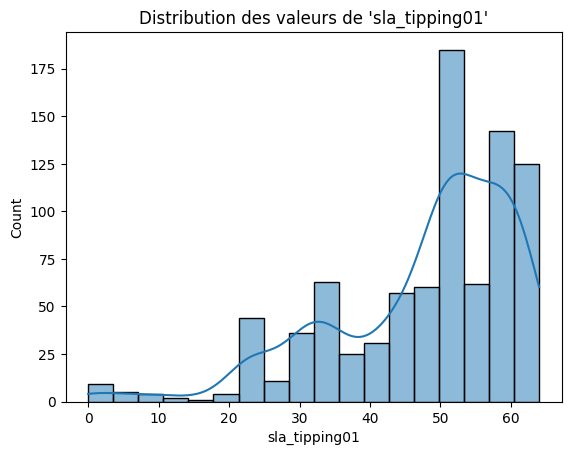

Dataframe saved to pickle file: ../import/workloads_legacyless63.pickle


In [ ]:
dftipping = dfloaded[dfloaded["sla_tipping01"]==63][["sla_tipping01", "combined_column"]].drop_duplicates()
dftipping.reset_index(drop=True, inplace=True)
print("LIST", dftipping.to_string(index=True))
print()

import random

dfnotipping64 = dfloaded[dfloaded['sla_tipping01']<63]
wlno64 = dfnotipping64["combined_column"].unique().tolist()
print("WORKLOADS without tipping <63:", len(wlno64))
dftipping64 = dfloaded[dfloaded["sla_tipping01"]>=63]
wl64 = dftipping64["combined_column"].unique().tolist()
print("WORKLOADS with tipping >= 63:", len(wl64))
random.shuffle(wl64)
newwl64 = wl64[0:int(len(wl64)*0.2)]
print("Selected WORKLOADS with tipping >= 63:", len(newwl64))
newlist = wlno64 + newwl64
print("Total WORKLOADS selected:", len(newlist))

## FILTER WITH THIS LINE !
df = dfloaded[dfloaded['combined_column'].isin(wlno64+newwl64)]
## NO FILTER WITH THIS LINE
#df = dfloaded.copy()
#OLD OLD df2 = df[~df['wl_clients'].isin(train_wl)]
allnewwl = df["combined_column"].unique().tolist()
print("After filter, total WORKLOADS selected:", len(allnewwl))
print("+++++++++++++++++++++++++++++++++")


import seaborn as sns
import matplotlib.pyplot as plt

# Supposons que votre DataFrame s'appelle df
# Afficher la distribution des valeurs de la colonne 'sla_tipping01'
tipping_per_workload = df.groupby('combined_column')['sla_tipping01'].first()
sns.histplot(tipping_per_workload, kde=True)

# Ajouter un titre
plt.title("Distribution des valeurs de 'sla_tipping01'")

# Afficher le graphique
plt.show()

# SAVE TO PICKLE!!
#obsdf = ObsSamplesDF(version="16")
#picklefiles="../import/workloads_legacyless63"
#savedfile = obsdf.saveToPickle(picklefiles, df)
#print("Dataframe saved to pickle file:", savedfile)


In [81]:
pd.options.mode.copy_on_write = True

workload = "V10 40 1.0 7 Un" # 64"V12.3 22 1.0 1 Ga" #63"V10 50 1.0 3 Pa" #62"V9 40 0.3 2 Ga" #0"V10 40 1.0 12 Un" #2"V9 40 1.0 12 Un" #10"V10 40 1.0 7 Un
dfwl = df[df["combined_column"]==workload]
dfwl["buf_size_mb"] = df.apply(lambda row: int(row["buf_size"])/1024/1024 , axis=1)
#df[df["combined_column"]==workload]["sla_tipping01"].tolist()
#df[df["combined_column"]==workload]["buf_size_idx"].tolist()

dfwl[new_columns] = dfwl.apply(lambda row: computeOptimalPolicyPerformance(row, new_columns), axis=1) #, result_type='expand' )
#df.loc[df["combined_column"]==workload, "OP_USLA"] = df.apply(lambda row: compute_OP_USLA(int(row["buf_size_idx"]), int(row["sla_tipping01"])), axis=1) 
#df.loc[df["combined_column"]==workload, "OP_CRAM"] = df.apply(lambda row: compute_OP_CRAM(int(row["sla_tipping01"]), int(row["buf_size_idx"])), axis=1) 
#df.loc[df["combined_column"]==workload, "OP_OB_CRAM"] = df.apply(lambda row: compute_OP_OVER_BUDGET_CRAM(int(row["sla_tipping01"])), axis=1)
#df.loc[df["combined_column"]==workload, "OP_OB_USLA"] = df.apply(lambda row: compute_OP_OVER_BUDGET_USLA(int(row["sla_tipping01"])), axis=1)

print(f"Workload {workload} with Optimal Policy computed. Show results...")
#df.loc[df["combined_column"]==workload, "buf_size_idx","OP_USLA"]
#dfresults = df[df["combined_column"]==workload][["buf_size_idx","sla_tipping01", "buf_size_mb", "sysbench_filtered.latency_mean"]+new_columns]
dfresults = dfwl[["buf_size_idx","sla_tipping01", "buf_size_mb", "sysbench_filtered.latency_mean"]+new_columns]
dfresults.reset_index(drop=True, inplace=True)
print(dfresults.to_string(index=True))

Workload V10 40 1.0 7 Un with Optimal Policy computed. Show results...
    buf_size_idx  sla_tipping01  buf_size_mb  sysbench_filtered.latency_mean  OP_BUDGET01  OP_USLA01  OP_CRAM01  OP_OB_USLA01  OP_OB_CRAM01
0             63           10.0       8192.0                       17.386310            9          0      76160             0          7040
1             62           10.0       8064.0                       17.220327            8          0      67968             0          7040
2             61           10.0       7936.0                       17.054345            7          0      59904             0          7040
3             60           10.0       7808.0                       16.971354            6          0      51968             0          7040
4             59           10.0       7680.0                       16.929688            5          0      44160             0          7040
5             58           10.0       7552.0                       17.358021            4